In [1]:
import pandas as pd
import pickle

In [2]:
import statsmodels.api as sm
from statsmodels.formula.api import glm

In [3]:
from sklearn.preprocessing import StandardScaler


In [4]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#finalgen_samples = pd.read_csv('../final_gen.csv')['sample_name']
last_gen = pd.read_csv('../key_files/final_gen.csv')['sample_name']
## eliminate site 33 
last_gen = last_gen[~last_gen.str.startswith('33_')]
## eliminate site 33 
samples = last_gen.to_list()

In [19]:
clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
#clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

sites_af = pd.Series(samples).str.split('_').str[0].astype(int)

sites_af.name = 'site'


In [20]:
env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

In [21]:
env_variable = env['bio12']

In [22]:
# Standardize the environmental variable
scaler = StandardScaler()
env_variable_scaled = scaler.fit_transform(env_variable.values.reshape(-1, 1))

In [23]:
pd.DataFrame(env_variable_scaled).to_csv('env_bio12.csv',index=None)

In [24]:
env_site_scaled = pd.concat([env['site'],pd.Series(env_variable_scaled.flatten())],axis=1)

In [25]:
env_site_scaled.columns = ['site', 'env_scaled']

In [54]:
env_variable

,0
0,-0.153612
1,-0.153612
2,-0.153612
3,-0.153612
4,-0.153612
...,...
343,-0.924914
344,-0.924914
345,-0.924914
346,-0.924914


In [55]:
env_variable = pd.read_csv('env_bio12.csv')

In [56]:
partition_0 = pd.read_csv('../baypass_lastgen/individual_gfiles_last_gen/partition_0.txt',header=None) #= pd.read_csv(path_analysis + 'individual_gfiles/partition_0.txt',header=None)

In [57]:
pickle_file_path = '../baypass_lastgen/individual_gfiles_last_gen/column_names_partition_0'
with open(pickle_file_path, 'rb') as file:
    data0 = pickle.load(file)

In [58]:
partition_0.columns = data0

In [59]:
## eliminate site 33 

site_33_delete = [i for i in partition_0.columns if i.startswith('33_')]

partition_0 = partition_0.drop(site_33_delete,axis=1)

## eliminate site 33 

In [60]:
minor_columns = partition_0.filter(like='minor')
major_columns = partition_0.filter(like='major')

In [61]:
# Properly calculate total allele counts by summing corresponding minor and major allele counts
total_allele_counts = minor_columns.values + major_columns.values

# Create a new DataFrame for total counts with proper column names
total_allele_counts_df = pd.DataFrame(total_allele_counts, columns=minor_columns.columns.str.replace('_minor', '_total'))

In [62]:

# Preparing data for binomial regression
# Minor allele counts as the response variable (successes)
minor_alleles = minor_columns.T.reset_index(drop=True)
major_columns = major_columns.T.reset_index(drop=True)

# Total allele counts as the number of trials (total attempts)
total_alleles = total_allele_counts_df.T.reset_index(drop=True)


In [63]:
successes = minor_alleles.iloc[:,1]
failures = major_columns.iloc[:,1]

In [64]:
## convert the bio12 to precit into an array and add a constant 
bio12_predict = env_site_scaled[env_site_scaled['site'] == 1]['env_scaled'][0]



In [65]:
env_site_scaled_unique = env_site_scaled.drop_duplicates().set_index('site')

In [66]:
env_site_scaled_unique.head(1)

,env_scaled
site,
1,-0.153612


In [83]:
env_variable.shape

(348, 1)

In [86]:
env_variable

,0
0,-0.153612
1,-0.153612
2,-0.153612
3,-0.153612
4,-0.153612
...,...
343,-0.924914
344,-0.924914
345,-0.924914
346,-0.924914


In [84]:
successes.shape

(348,)

In [85]:
successes

0      227
1      155
2       42
3       38
4      120
      ... 
343     34
344      3
345     33
346     22
347     34
Name: 4998, Length: 348, dtype: int64

In [67]:
# Running binomial regression for each SNP separately
coefficients_df = {}

for i in range(minor_alleles.shape[1]):
    # Prepare response (successes, failures) and predictors (environmental variable)
    successes = minor_alleles.iloc[:,i]
    failures = major_columns.iloc[:,i]
    # Set up the binomial regression model
    X = sm.add_constant(env_variable)  # Adding constant for intercept
    y = pd.concat([successes,failures],axis=1)
    # Fit the modelb
    model = sm.GLM(y, X, family=sm.families.Binomial())
    result = model.fit()

    # Extract slope (coefficient for environmental variable) and p-value
    slope = result.params[1]  # Coefficient for the environmental variable
    p_value = result.pvalues[1]  # P-value for the environmental variable

    all_sites_pred_proba = []
    for site, row in env_site_scaled_unique.iterrows():
        # Predict the probability using the logistic model
        X_new = np.column_stack((np.ones(1), np.array([row['env_scaled']])))
        predicted_probability = result.predict(X_new)  # This gives the log-odds
        all_sites_pred_proba.append(predicted_probability[0])
    # Append the results to the DataFrame

    all_sites_pred_proba.append(slope)
    all_sites_pred_proba.append(p_value)
    coefficients_df[i] = all_sites_pred_proba
    
    # Collect resul

In [68]:
coefficients_df = pd.DataFrame(coefficients_df).T

In [69]:
coefficients_df.shape

(4999, 32)

In [70]:
site1_predict_proba = coefficients_df[1]

In [157]:
## get the genotype matrix 
genotype_counts = pd.read_csv('../leave_1_out/genotype_counts_fullgenome231ecotypes.csv', nrows = 4999).drop('Unnamed: 0', axis=1)

In [158]:
## centralize it so that it goes from 0 to 1 likethe probabilities
## having a 1 is having a lot of the alternative alle, to the probability that there is a succes should be high 
genotype_counts = genotype_counts.replace({2: 1, 1: 0.5, 0: 0})

In [159]:
## for each site, subrstract the actual value by the probability fo getting a success 
genotype_counts_subs = genotype_counts.sub(site1_predict_proba, axis=0)

In [147]:
## ge tthe absolute value 
genotype_counts_subs = abs(genotype_counts_subs)

In [150]:
## sum over ecotypes 
go = genotype_counts_subs.sum(axis=0)

<Axes: ylabel='Count'>

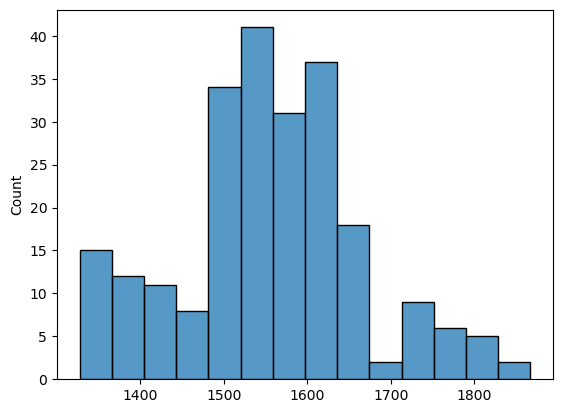

In [154]:
## dsitribution of go 
sns.histplot(go)

In [128]:
coefficients_df.columns = [1,  2,  4,  5,  6,  9, 10, 11, 12, 13, 23, 24, 25, 26, 27, 28, 32, 33,
       37, 42, 43, 45, 46, 48, 49, 52, 53, 54, 55, 57, 60, 'slope', 'pvalue']

<Axes: xlabel='pred_proba', ylabel='Count'>

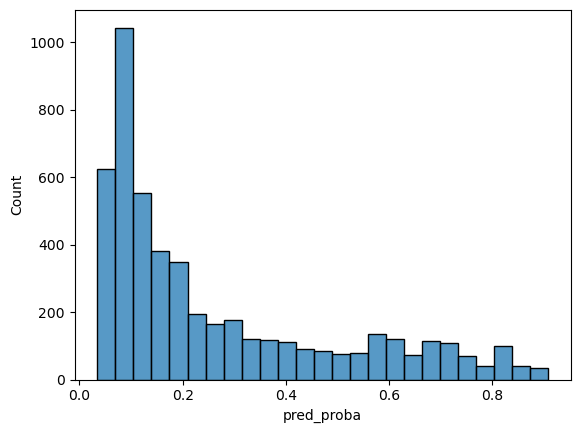

In [93]:
sns.histplot(coefficients_df['pred_proba'])

In [97]:
coefficients_df.loc[coefficients_df['pred_proba']>0.5]

,slope,pvalue,pred_proba
10,0.203323,1.965670e-38,0.813770
16,0.177587,8.776817e-42,0.698929
35,0.203323,1.965670e-38,0.813770
60,0.177587,8.776817e-42,0.698929
66,0.186576,2.991480e-45,0.704771
...,...,...,...
4975,0.106631,1.949882e-19,0.546638
4982,0.145222,9.475936e-33,0.610953
4983,0.155166,1.232850e-36,0.621196
4987,0.116454,5.582012e-22,0.602205


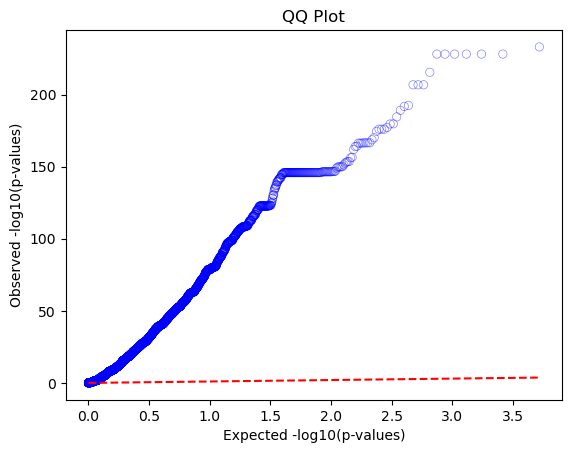

In [129]:
observed_quantiles = -np.log10(np.sort(coefficients_df['pvalue'].values))

# Expected quantiles from the uniform distribution
expected_quantiles = -np.log10(np.linspace(1 / len(coefficients_df['pvalue']), 1, len(coefficients_df['pvalue'])))

# QQ plot
sns.scatterplot(x = expected_quantiles, y = observed_quantiles, edgecolor='b', facecolor='none', alpha=0.5)
plt.plot([min(expected_quantiles), max(expected_quantiles)], [min(expected_quantiles), max(expected_quantiles)], 'r--')

plt.xlabel("Expected -log10(p-values)")
plt.ylabel("Observed -log10(p-values)")
plt.title(f'QQ Plot')

plt.show()

In [117]:
coefficients_df['pvalue'].unique()

array([8.17162954e-01, 8.58518224e-05, 1.85612522e-01, ...,
       1.08041784e-20, 7.42600016e-24, 5.29329426e-04])

In [84]:
result.params

const    7.960043e+17
x1      -9.474735e+16
dtype: float64

In [71]:
import os

In [72]:
files = os.listdir('../baypass_lastgen/individual_gfiles_last_gen/')

In [73]:
partitions = [int(file.split('_')[1].replace('.txt', '')) for file in files if '.txt' in file]

In [74]:
partitions.sort()

In [75]:
partitions[-1]

209

In [76]:
len(partitions)

210

In [77]:
pwd -P

'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/binomial_regression_lastgen'

In [78]:
import random
import subprocess

In [81]:
# create sbatch files to submit on cedar server
shfiles = []
for partition in partitions:
    seed = random.randint(1,100000000)
    file = f'shfiles/partition_{partition}.sh'
    cmd = f'python run_partition_binomial_reg_last_gen.py {partition}'
    text = f'''#!/bin/bash
#SBATCH --job-name=run_partition_binomial_reg{partition}
#SBATCH --time=4:00:00  # Time limit set to 4 days
#SBATCH --ntasks=1
#SBATCH --mem-per-cpu=30gb
#SBATCH --output=run_partition_binomial_reg{partition}_%j.out
#SBATCH --mail-user=tbellagio@carnegiescience.edu
#SBATCH --mail-type=FAIL

module load python/3.11_conda
conda activate /home/tbellagio/miniforge3/envs/pipeline_snakemake
export LD_LIBRARY_PATH="/home/tbellagio/miniforge3/envs/run_baypass/lib:$LD_LIBRARY_PATH"
cd /carnegie/nobackup/scratch/tbellagio/gea_grene-net/binomial_regression_lastgen
{cmd}

'''
    with open(file, 'w') as o:
        o.write("%s" % text)
    shfiles.append(file)

In [87]:
subprocess.run(["sbatch", shfiles[0]], check=True)

Submitted batch job 56957


CompletedProcess(args=['sbatch', 'shfiles/partition_0.sh'], returncode=0)

In [88]:
## now run the shfiles
for shfile in shfiles:
    # Submit each sbatch script to the SLURM scheduler
    subprocess.run(["sbatch", shfile], check=True)

Submitted batch job 56958
Submitted batch job 56959
Submitted batch job 56960
Submitted batch job 56961
Submitted batch job 56962
Submitted batch job 56963
Submitted batch job 56964
Submitted batch job 56965
Submitted batch job 56966
Submitted batch job 56967
Submitted batch job 56968
Submitted batch job 56969
Submitted batch job 56970
Submitted batch job 56971
Submitted batch job 56972
Submitted batch job 56973
Submitted batch job 56974
Submitted batch job 56975
Submitted batch job 56976
Submitted batch job 56977
Submitted batch job 56978
Submitted batch job 56979
Submitted batch job 56980
Submitted batch job 56981
Submitted batch job 56982
Submitted batch job 56983
Submitted batch job 56984
Submitted batch job 56985
Submitted batch job 56986
Submitted batch job 56987
Submitted batch job 56988
Submitted batch job 56989
Submitted batch job 56990
Submitted batch job 56991
Submitted batch job 56992
Submitted batch job 56993
Submitted batch job 56994
Submitted batch job 56995
Submitted ba

In [89]:
loci_names = [file for file in files if 'loci' in file]

In [90]:
partition = 0 

In [91]:
pickle_file_path = f'../baypass_lastgen/individual_gfiles_last_gen/loci_partition_{partition}'
with open(pickle_file_path, 'rb') as file:
    loci_f = pickle.load(file)

In [93]:
partitions_r = {}
for i in range(len(partitions)):
    pickle_file_path = f'../baypass_lastgen/individual_gfiles_last_gen/loci_partition_{i}'
    with open(pickle_file_path, 'rb') as file:
        loci_f = pickle.load(file)
    results = pd.read_csv(f'results_bio12/partition{i}.csv')
    results['snp_id'] = loci_f
    partitions_r[i] = results

In [94]:
results = pd.concat(partitions_r).reset_index(drop=True)

In [95]:
results

,slope,pvalue,snp_id
0,-0.071916,7.601459e-08,1_346
1,-0.094221,1.088035e-04,1_353
2,0.072690,7.963494e-05,1_363
3,-0.224875,9.784067e-16,1_395
4,-0.224875,9.784067e-16,1_396
...,...,...,...
1048630,0.186622,3.190082e-26,5_26975078
1048631,-0.054703,1.989126e-02,5_26975121
1048632,-0.054703,1.989126e-02,5_26975148
1048633,0.021885,6.410246e-02,5_26975272


In [96]:
results.to_csv('bio12_binomial_reg_results_last_gen.csv',index=None)

In [87]:
len(results['snp_id'].unique())

1048635

In [89]:
1048635 - 1048635

0

In [73]:
len(results)

1055248

In [66]:
all_loci = []
for i in loci_names:
    pickle_file_path = f'../baypass_lastgen/individual_gfiles_last_gen/{i}'
    with open(pickle_file_path, 'rb') as file:
        loci_f = pickle.load(file)
    all_loci.append(loci_f)

In [67]:
flattened_loci = [item for sublist in all_loci for item in sublist]

In [68]:
len(flattened_loci)

1048635

In [74]:
1054574 - 1055248

-674

In [ ]:
biovar = 'bio12'

binom = pd.read_csv(f'{biovar}_binomial_reg_results_last_gen.csv')

binom['chrom'] = binom['snp_id'].str.split('_').str[0].astype(int)
binom['pos'] = binom['snp_id'].str.split('_').str[1].astype(int)

/tmp/ipykernel_642524/3423637642.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


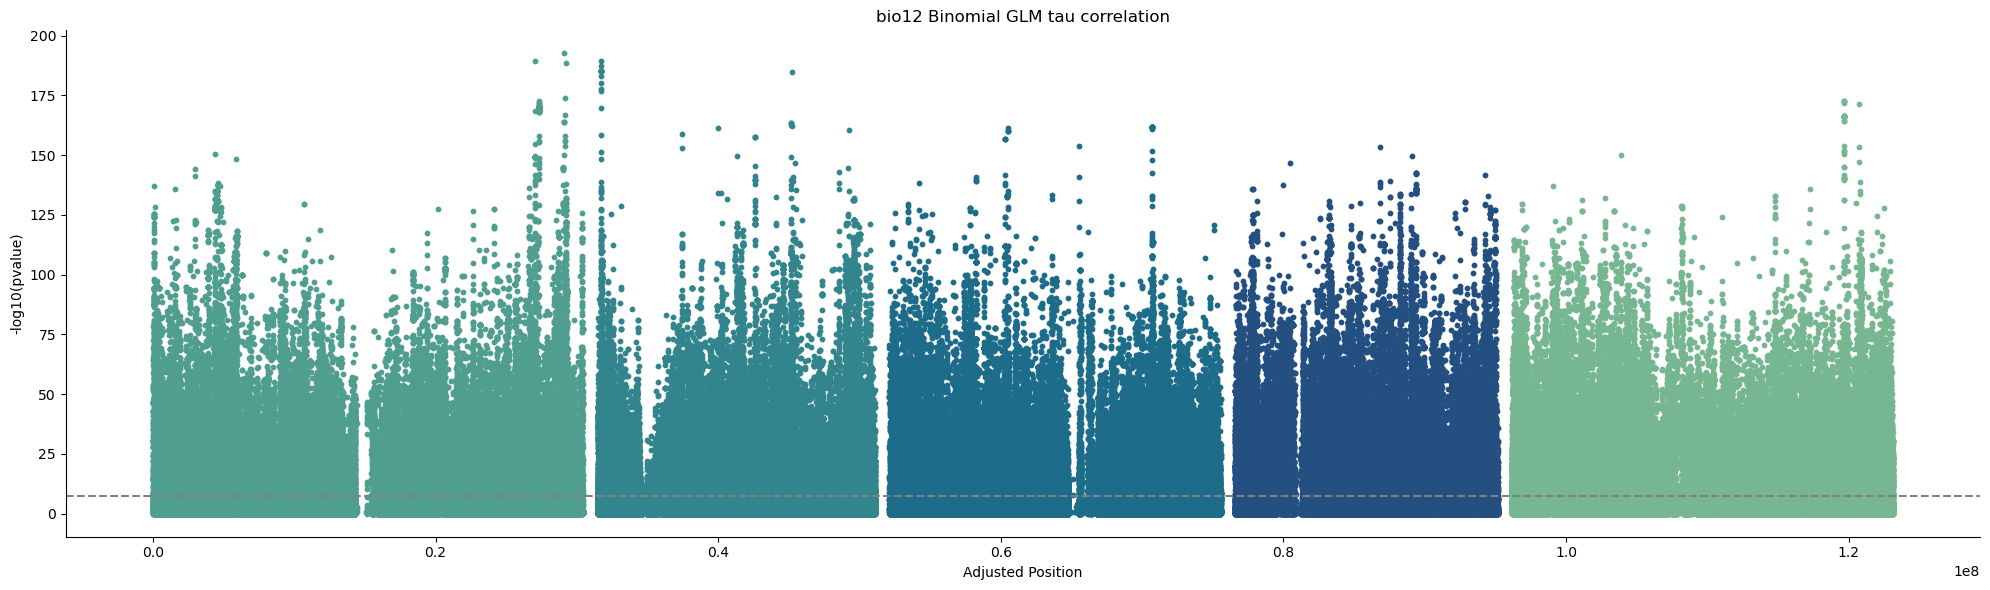

In [23]:
threshold_value = 0.05 / len(binom)

#sm.qqplot(pvalues['pvalue'], line ='45') 
#py.show() 

df = binom[['pvalue', 'pos', 'chrom']].copy()

colors = sns.color_palette("crest", n_colors = 5)

# Parsing chromosome number and position
df['chromosome'] = df['chrom']
df['position'] = df['pos']
df['-log10(pvalue)'] = -np.log10(df['pvalue'])

# Calculate the offset for each chromosome to prevent overlap
chromosome_offsets = {}
offset = 0
for chrom in sorted(df['chromosome'].unique()):
    chromosome_offsets[chrom] = offset
    max_position = df[df['chromosome'] == chrom]['position'].max()
    offset += max_position + 1000000  # Adding 1 million as a buffer between chromosomes

# Apply offsets to positions
df['adjusted_position'] = df.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)

# Creating the Manhattan plot
plt.figure(figsize=(20, 6))

for chrom in sorted(df['chromosome'].unique()):
    subset = df[df['chromosome'] == chrom]
    plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)

# Aesthetics
plt.xlabel('Adjusted Position')
plt.ylabel('-log10(pvalue)')
#plt.title('Manhattan Plot')
#plt.grid(axis='y')
#plt.legend(title="Chromosome", bbox_to_anchor=(1.05, 1), loc='upper left')
ax = plt.gca()  # Get current axes
ax.spines['top'].set_visible(False)  # Remove the top spine
ax.spines['right'].set_visible(False)
# Threshold line (optional)
threshold = -np.log10(threshold_value)
plt.axhline(y=threshold, color='grey', linestyle='dashed')
plt.title(f'{biovar} Binomial GLM tau correlation')  # Set the title

# Show the plot
plt.tight_layout()
plt.savefig(f'manhattan_binom_{biovar}.png')
plt.show()